In [158]:
%pip install scipy


Note: you may need to restart the kernel to use updated packages.


In [159]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from IPython.display import clear_output
import time

In [160]:
class Agent:
    def __init__(self, id, preferences, cost_function, bundle, initial_wealth, vision, position, metabolic_rate):
        self.id = id
        self.preferences = preferences
        self.cost_function = cost_function
        self.bundle = bundle
        self.utility = initial_wealth
        self.vision = vision
        self.position = position
        self.metabolic_rate = metabolic_rate
    
    def utility_function(self, resource):
        util = resource**self.preferences
        return util


    def move(self, environment, agents):
        next_position = self.position
        next_utility = self.utility_function(environment.get_resource_at(next_position))
        for dx in range(-self.vision, self.vision + 1):
            for dy in range(-self.vision, self.vision + 1):
                potential_position = (self.position[0] + dx, self.position[1] + dy)
                if environment.is_valid_position(potential_position):
                    potential_utility = self.utility_function(environment.get_resource_at(potential_position))
                    agent_collision = 0
                    for a in agents:
                        if potential_position == a.position:
                            agent_collision += 1
                    if  agent_collision == 0:
                        if potential_utility> next_utility:
                            next_position = potential_position
                            next_utility = potential_utility
        self.position = next_position
        self.utility += next_utility


    def metabolism(self, agents):
        if self.utility - self.metabolic_rate <=0:
            agents.remove(self)
        else:
            self.utility -= self.metabolic_rate



In [161]:
def generate_landscape(height, width, resource_fn, max_resource=10):
    y, x = np.meshgrid(np.linspace(0, 1, height), np.linspace(0, 1, width), indexing='ij')
    z = np.clip(resource_fn(x, y), 0, None)
    return z / z.max() * max_resource if z.max() > 0 else z

class Environment:
    def __init__(self, height, width, resource_fn, max_resource=10):
        self.max_landscape = generate_landscape(height, width, resource_fn, max_resource)
        self.landscape = self.max_landscape.copy()

    def is_valid_position(self, position):
        x, y = position
        return 0 <= x < self.landscape.shape[0] and 0 <= y < self.landscape.shape[1]

    def get_resource_at(self, position):
        return self.landscape[position]

    def set_resource_at(self, position, value):
        max_value = self.max_landscape[position]
        self.landscape[position] = np.clip(value, 0, max_value)

    def deplete_resource_at(self, position, amount=1.0):
        self.set_resource_at(position, self.get_resource_at(position) - amount)

    def regrow_resources(self, growth_rate=0.1):
        # Regrow each cell toward its local carrying capacity (max_landscape).
        deficit = self.max_landscape - self.landscape
        self.landscape += growth_rate * deficit
        self.landscape = np.clip(self.landscape, 0, self.max_landscape)



In [169]:
def get_truncated_normal(mean=0.5, sd=0.1, low=0, high=1):
    # Truncnorm takes bounds in terms of standard deviations from the mean
    a = (low - mean) / sd
    b = (high - mean) / sd
    return sp.stats.truncnorm(a, b, loc=mean, scale=sd).rvs()

In [163]:
def initialize(num_agents, environment_size, landscape_function, max_resource, metabolic_rate, preferences):
    env = Environment(environment_size[0], environment_size[1], landscape_function, max_resource)
    # Initialize agents with random positions and parameters
    agents = []
    for agent in range(num_agents):
        # Stochastic Params
        position = (np.random.randint(0, env.landscape.shape[0]), np.random.randint(0, env.landscape.shape[1]))
        initial_wealth = 0 + env.get_resource_at(position)  # Initial wealth for each agent
        initial_bundle = None
        agent_preferences =  get_truncated_normal(preferences, sd=.1, low = 0, high = 1)
        #preferences = preferences
        vision = 1  # Vision range for movement
        cost_fn = lambda resource: 0.1 * resource  # Simple cost function
        
        agents.append(Agent(agent, agent_preferences, cost_fn, initial_bundle, initial_wealth, vision, position, metabolic_rate))
    return agents, env

In [164]:
def deplete_resources(agents, env, depletion_amount=1.0):
    """Deplete resources at the cells occupied by agents."""
    for agent in agents:
        env.deplete_resource_at(agent.position, amount=depletion_amount)


def regrow_resources(env, growth_rate=0.1):
    """Regrow resources everywhere toward each cell's max value."""
    env.regrow_resources(growth_rate=growth_rate)


def update(agents, env, resource_depletion_rate, resource_regrowth_rate):
    for a in agents:
        a.move(env, agents)
        a.metabolism(agents)


    deplete_resources(agents, env, resource_depletion_rate)

    regrow_resources(env, resource_regrowth_rate)

    return



In [165]:
def observe(agents, env):
    plt.imshow(env.landscape, cmap='viridis')
    plt.colorbar(label='Resource Level')
    utilities = [agent.utility_function(env.get_resource_at(agent.position)) for agent in agents]
    scatter = plt.scatter(
        [agent.position[1] for agent in agents],
        [agent.position[0] for agent in agents],
        c=utilities,
        cmap='plasma',
        edgecolors='black',
        label='Agents'
    )
    plt.colorbar(scatter, label='Agent Utility')
    plt.title('Environment Landscape')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()



In [166]:
def run(time_steps, num_agents, environment_size, landscape_function, max_resource, resource_depletion_rate, resource_regrowth_rate, metabolic_rate, preferences):
    agents, env = initialize(num_agents, environment_size, landscape_function, max_resource, metabolic_rate, preferences)
    for t in range(time_steps):

        update(agents, env, resource_depletion_rate, resource_regrowth_rate)

        observe(agents, env)

        clear_output(wait=True)

        time.sleep(.01)



    observe(agents, env)



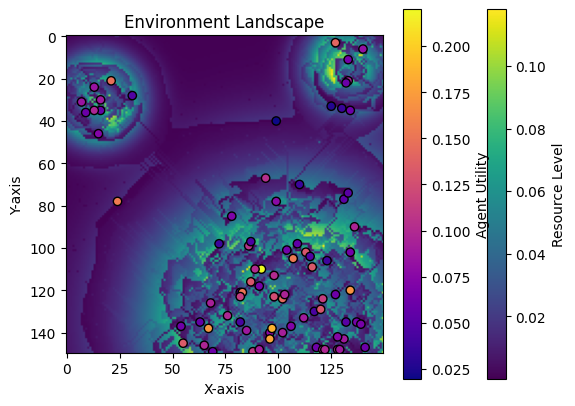

In [172]:
f = lambda x, y: np.exp(-((x - 0.9) ** 2 + (y - 0.1) ** 2)/.01)+ np.exp(-((x - 0.1) ** 2 + (y - 0.2) ** 2)/.01) + np.exp(-((x - 0.7) ** 2 + (y - 0.9) ** 2)/.1)

run(time_steps=400, num_agents=1000, environment_size=(150, 150), landscape_function=f, max_resource=1, resource_depletion_rate=1, resource_regrowth_rate=.001, metabolic_rate=.3, preferences=.5)